In [3]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_context_failure(alpha_max, threshold_radius, sigma, T=30, dt=0.01):
    steps = int(T / dt)
    x, y, z = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    x[0], y[0] = 0.5, 0.0 # Start inside the 'Healthy Zone'

    alpha_history = []

    for i in range(1, steps):
        # Calculate current 'distance' from the healthy center
        radius = np.sqrt(x[i-1]**2 + y[i-1]**2)

        # State-Dependent Alpha: If radius > threshold, alpha drops to near zero
        if radius < threshold_radius:
            alpha_t = alpha_max
        else:
            alpha_t = alpha_max * 0.05 # Contextual collapse

        alpha_history.append(alpha_t)

        # Add a bit of 'drift' to the motor plan so it eventually leaves the zone
        dx = (-y[i-1] + 0.05 * x[i-1]) * dt # The 0.05 causes an outward spiral
        dy = (x[i-1] + 0.05 * y[i-1]) * dt

        area_element = (x[i-1] * dy - y[i-1] * dx)
        dz = alpha_t * area_element + sigma * np.random.normal(0, np.sqrt(dt))

        x[i] = x[i-1] + dx
        y[i] = y[i-1] + dy
        z[i] = z[i-1] + dz

    return x, y, z, alpha_history

# --- Run the Contextual Trial ---
x_3, y_3, z_3, a_3 = simulate_context_failure(alpha_max=4.0, threshold_radius=1.5, sigma=0.05)

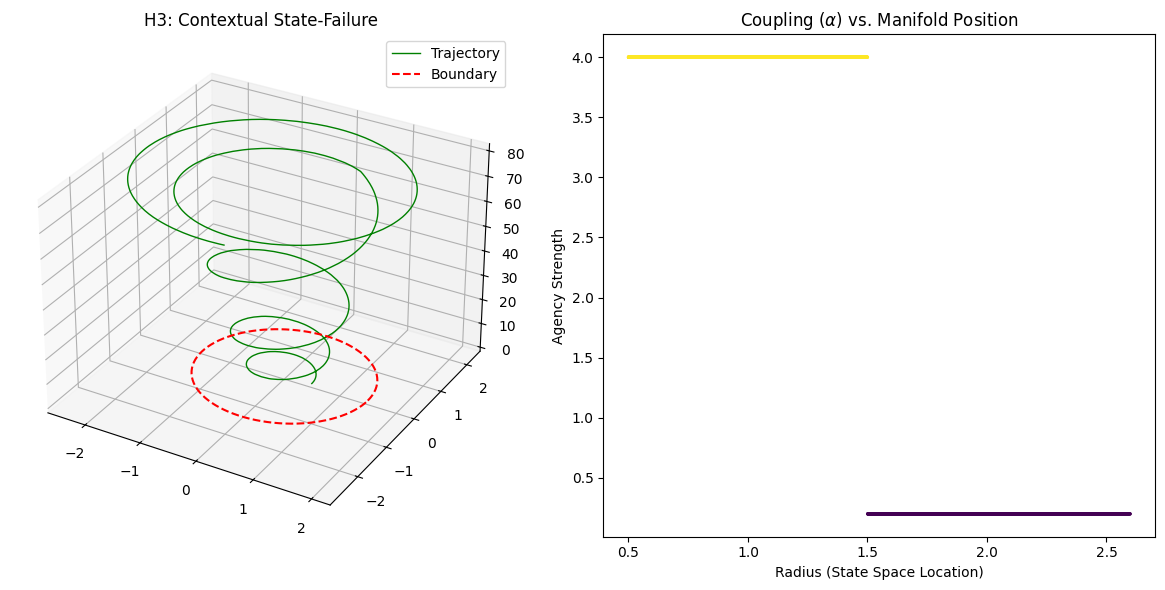

In [4]:
fig = plt.figure(figsize=(12, 6))

# 3D View
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(x_3, y_3, z_3, lw=1, color='green', label='Trajectory')
# Draw a 'floor' representing the healthy threshold
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(1.5*np.cos(theta), 1.5*np.sin(theta), 0, color='red', linestyle='--', label='Boundary')
ax1.set_title("H3: Contextual State-Failure")
ax1.legend()

# Alpha vs Radius View
ax2 = fig.add_subplot(1, 2, 2)
radii = np.sqrt(x_3[:-1]**2 + y_3[:-1]**2)
ax2.scatter(radii, a_3, c=a_3, cmap='viridis', s=2)
ax2.set_title(r"Coupling ($\alpha$) vs. Manifold Position")
ax2.set_xlabel("Radius (State Space Location)")
ax2.set_ylabel("Agency Strength")

plt.tight_layout()
plt.show()